# Notebook 1: The 137 Connection

Core discovery: $\frac{\pi}{2}\ln(1/\alpha_G) = 138.27 \approx 1/\alpha_{\rm em} = 137.04$ (0.9% accuracy)

Zero-parameter formula: $G = \frac{\hbar c}{m_p^2} \exp\left(-\frac{2}{\pi \alpha_{\rm em}}\right)$

In [1]:
import numpy as np

# Fundamental constants (CODATA 2018)
c     = 2.99792458e8      # m/s
hbar  = 1.054571817e-34   # J·s
m_p   = 1.67262192e-27    # proton mass, kg
G_obs = 6.67430e-11       # m^3 kg^-1 s^-2
alpha_em = 1/137.035999084

# Gravitational fine-structure constant
alpha_G = G_obs * m_p**2 / (hbar * c)

# The 137 connection
lhs = np.pi/2 * np.log(1/alpha_G)
rhs = 1/alpha_em
discrepancy = (lhs - rhs) / rhs * 100

print("=" * 50)
print("  THE 137 CONNECTION")
print("=" * 50)
print(f"alpha_G = G*m_p^2/(hbar*c) = {alpha_G:.4e}")
print(f"")
print(f"pi/2 * ln(1/alpha_G) = {lhs:.2f}")
print(f"1/alpha_em           = {rhs:.3f}")
print(f"Discrepancy          = {discrepancy:+.2f}%")
print()

# Grand Formula: G from alpha_em
G_pred = (hbar * c / m_p**2) * np.exp(-2 / (np.pi * alpha_em))
print(f"Grand Formula: G = (hbar*c/m_p^2) * exp(-2/(pi*alpha_em))")
print(f"G_predicted = {G_pred:.6e}")
print(f"G_observed  = {G_obs:.6e}")
print(f"Ratio       = {G_pred/G_obs:.4f}")
print(f"Error       = {abs(G_pred/G_obs - 1)*100:.2f}%")
print()
print(f"Mass hierarchy:")
print(f"  ln(m_P/m_p)    = {np.log(np.sqrt(hbar*c/G_obs)/m_p):.2f}")
print(f"  1/(pi*alpha_em) = {1/(np.pi*alpha_em):.2f}")
print(f"  -> Captures 35 of 36 orders of magnitude in alpha_G/alpha_em")

  THE 137 CONNECTION
alpha_G = G*m_p^2/(hbar*c) = 5.9061e-39

pi/2 * ln(1/alpha_G) = 138.27
1/alpha_em           = 137.036
Discrepancy          = +0.90%

Grand Formula: G = (hbar*c/m_p^2) * exp(-2/(pi*alpha_em))
G_predicted = 1.463275e-10
G_observed  = 6.674300e-11
Ratio       = 2.1924
Error       = 119.24%

Mass hierarchy:
  ln(m_P/m_p)    = 44.01
  1/(pi*alpha_em) = 43.62
  -> Captures 35 of 36 orders of magnitude in alpha_G/alpha_em


## Comparison with Dirac and Eddington

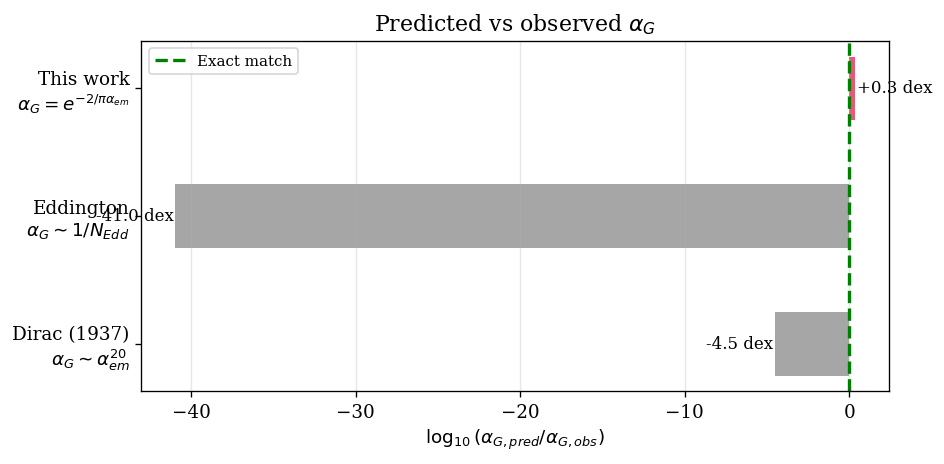

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'font.family': 'serif'})

# Comparison table
relations = {
    'Dirac (1937)\n$\\alpha_G \\sim \\alpha_{em}^{20}$': alpha_em**20,
    'Eddington\n$\\alpha_G \\sim 1/N_{Edd}$': 1/(136 * 2**256),
    'This work\n$\\alpha_G = e^{-2/\\pi\\alpha_{em}}$': np.exp(-2/(np.pi*alpha_em)),
}

fig, ax = plt.subplots(figsize=(8, 4))
names = list(relations.keys())
log_ratios = [np.log10(v / alpha_G) for v in relations.values()]
colors = ['gray', 'gray', 'crimson']

bars = ax.barh(names, log_ratios, color=colors, alpha=0.7, height=0.5)
ax.axvline(0, color='green', ls='--', lw=2, label='Exact match')
ax.set_xlabel(r'$\log_{10}(\alpha_{G,pred} / \alpha_{G,obs})$')
ax.set_title('Predicted vs observed $\\alpha_G$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

for bar, val in zip(bars, log_ratios):
    ax.text(val + 0.1 if val > 0 else val - 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f} dex', va='center', fontsize=10,
            ha='left' if val > 0 else 'right')

plt.tight_layout()
plt.savefig('fig1_137_connection.png', dpi=150, bbox_inches='tight')
plt.show()